In [48]:
# ================== PARAMÈTRES GLOBAUX ==================
IMG_SIZE = 224
DROPOUT_VAL = 0.2 

# ================== INSTALLS ==================
!pip install -q grad-cam pydicom nibabel pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

# ================== IMPORTS ==================
import os, glob, random
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import pydicom
import nibabel as nib

from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms.functional as TF

# ================== PREPROCESSING ==================
def apply_bone_window(dcm, window_center=400, window_width=800):
    img = dcm.pixel_array.astype(np.float32)
    slope = float(getattr(dcm, 'RescaleSlope', 1.0))
    intercept = float(getattr(dcm, 'RescaleIntercept', 0.0))
    img = slope * img + intercept

    lower = window_center - window_width / 2
    upper = window_center + window_width / 2

    img = np.clip(img, lower, upper)
    img = (img - lower) / (upper - lower + 1e-6)
    return img

# ================== DATASET ==================
class RSNADatasetAug(Dataset):
    def __init__(self, df, image_dir, seg_dir=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.seg_dir = seg_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def get_anatomical_centers(self, uid, num_slices):
        seg_path = os.path.join(self.seg_dir, f"{uid}.nii.gz")
        if os.path.exists(seg_path):
            try:
                data = nib.load(seg_path).get_fdata()
                centers = []
                for v_idx in range(1, 8):
                    z = np.where(data == v_idx)[2]
                    if len(z) > 0:
                        mid_z = int(np.median(z))
                        actual_idx = num_slices - mid_z - 1
                        centers.append(np.clip(actual_idx, 0, num_slices-1))
                    else:
                        centers.append(-1)
                return centers
            except:
                pass

        # fallback si segmentation manquante
        return np.linspace(int(num_slices * 0.2), int(num_slices * 0.8), 7).astype(int)

    def preprocess_slice(self, dcm):
        img = apply_bone_window(dcm)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        return img

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(np.float32)

        path = os.path.join(self.image_dir, uid)
        slices_paths = sorted(
            glob.glob(os.path.join(path, "*.dcm")),
            key=lambda x: int(os.path.basename(x).replace('.dcm', ''))
        )

        num_slices = len(slices_paths)
        centers = self.get_anatomical_centers(uid, num_slices)
        vertebrae_stacks = []

        for mid in centers:
            if mid == -1:
                vertebrae_stacks.append(np.zeros((7, IMG_SIZE, IMG_SIZE), dtype=np.float32))
                continue

            stack = []
            for offset in range(-3, 4):
                idx_s = max(0, min(num_slices-1, mid + offset))
                dcm = pydicom.dcmread(slices_paths[idx_s])
                stack.append(self.preprocess_slice(dcm))

            vertebrae_stacks.append(np.stack(stack, axis=0))

        x = torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32)
        y = torch.tensor(labels, dtype=torch.float32)

        if self.augment:
            x = self._augment_stack(x)

        return x, y

    def _augment_stack(self, stack):
        if random.random() > 0.5:
            stack = torch.flip(stack, dims=[-1])

        augmented = torch.zeros_like(stack)
        for v in range(7):
            img = stack[v]
            angle = random.uniform(-10, 10)
            translate = (
                int(random.uniform(-0.05, 0.05) * IMG_SIZE),
                int(random.uniform(-0.05, 0.05) * IMG_SIZE)
            )
            augmented[v] = TF.affine(
                img, angle=angle, translate=translate,
                scale=1.0, shear=0.0
            )
        return augmented

# ================== MODÈLE ==================
class MultiVertebraModel(nn.Module):
    def __init__(self, dropout=DROPOUT_VAL):
        super().__init__()
        base = models.resnet18(weights="DEFAULT")
        base.conv1 = nn.Conv2d(7, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w)
        feat = self.encoder(x).view(bs * nv, -1)
        feat = self.dropout(feat)
        logits = self.fc(feat)
        return logits.view(bs, nv)

print("✅ Cellule 1 ")

✅ Cellule 1 


In [3]:
import nibabel as nib
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def esplora_segmentazioni(seg_dir, num_exemple=1):
    # je cherche .nii ET .nii.gz pour être sûre
    seg_files = [f for f in os.listdir(seg_dir) if f.endswith(('.nii', '.nii.gz'))]
    
    if not seg_files:
        print(f"Errore: Nessun file trovato in {seg_dir}")
        return

    for _ in range(num_exemple):
        choix_fichier = random.choice(seg_files)  # casuale quindi cambia ogni volta
        path_complet = os.path.join(seg_dir, file_scelto)
        
        img = nib.load(path_complet)
        data = img.get_fdata()
        
        # Correction d'orientation fréquente pour NIfTI sur Kaggle
        data = np.transpose(data, (1, 0, 2))
        data = np.flip(data, axis=0)

        print(f"Visualizzando: {choix_fichier} | Forma: {data.shape}")
        
        z_mid = data.shape[2] // 2
        coupe = [max(0, z_mid - 50), z_mid, min(data.shape[2]-1, z_mid + 50)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for i, f in enumerate(coupe):
            slice_data = data[:, :, f]
            #  j'utilise 'tab10' pour bien voir les 7 vertèbres (couleurs distinctes)
            im = axes[i].imshow(slice_data, cmap='tab10', vmin=0, vmax=7)
            axes[i].set_title(f"coupe (Z): {f}")
            axes[i].axis('off')
        
        plt.show()


SEG_DIR = os.path.join(BASE_PATH, "segmentations")
esplora_segmentazioni(SEG_DIR, num_esempi=1)

TypeError: esplora_segmentazioni() got an unexpected keyword argument 'num_esempi'

In [44]:
# ======================== IMPORTS ========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# ======================== FOCAL LOSS ========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

# ======================== TRAINING LOOP ========================
def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"🚀 Training on {DEVICE}")

    # ----------- Chargement CSV -----------
    df = pd.read_csv(TRAIN_CSV)

    # ----------- Filtrage par segmentations existantes -----------
    seg_ids = [
        f.replace(".nii.gz", "").replace(".nii", "")
        for f in os.listdir(SEG_DIR)
    ]

    df = df[df["StudyInstanceUID"].isin(seg_ids)].reset_index(drop=True)

    print("📊 Nombre de patients après filtrage segmentation :", len(df))
    assert len(df) >= 5, "❌ Dataset trop petit après filtrage segmentation"

    # ----------- SPLIT ROBUSTE (IMPORTANT) -----------
    val_size = max(1, int(0.15 * len(df)))

    train_df, val_df = train_test_split(
        df,
        test_size=val_size,
        random_state=42,
        shuffle=True
    )

    print(f"✅ Train patients : {len(train_df)} | Val patients : {len(val_df)}")

    # ----------- DATASETS & DATALOADERS -----------
    train_ds = RSNADatasetAug(
        train_df, TRAIN_IMAGES_DIR, SEG_DIR, augment=True
    )
    val_ds = RSNADatasetAug(
        val_df, TRAIN_IMAGES_DIR, SEG_DIR, augment=False
    )

    train_dl = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2)

    # ----------- MODÈLE / LOSS / OPTIM -----------
    model = MultiVertebraModel().to(DEVICE)

    criterion = FocalLoss(alpha=0.75, gamma=2)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=2e-4, weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )

    # ----------- EARLY STOPPING -----------
    EPOCHS = 15
    best_val_loss = float("inf")
    patience = 3
    counter = 0

    print("-" * 60)
    print(f"{'Epoch':<6} | {'TrainLoss':<10} | {'ValLoss':<10} | {'F1 micro':<8}")
    print("-" * 60)

    # ======================== TRAIN ========================
    for epoch in range(1, EPOCHS + 1):
        # ---- TRAIN ----
        model.train()
        train_loss = 0

        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dl)

        # ---- VALIDATION ----
        model.eval()
        val_loss = 0
        all_probs, all_labels = [], []

        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                val_loss += criterion(logits, y).item()

                all_probs.append(torch.sigmoid(logits).cpu().numpy())
                all_labels.append(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_dl)

        probs = np.concatenate(all_probs).flatten()
        labels = np.concatenate(all_labels).flatten()

        f1 = f1_score(labels, probs > 0.5, average="micro")

        print(f"{epoch:<6} | {avg_train_loss:<10.4f} | {avg_val_loss:<10.4f} | {f1:<8.4f}")

        scheduler.step(avg_val_loss)

        # ---- EARLY STOPPING ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "best_model.pth")
            counter = 0
            print("   ✅ Nouveau meilleur modèle sauvegardé")
        else:
            counter += 1
            print(f"   ⚠️ Pas d'amélioration ({counter}/{patience})")
            if counter >= patience:
                print("   ⏹️ Early stopping déclenché")
                break

        print("-" * 60)

    # ----------- RELOAD BEST MODEL -----------
    model.load_state_dict(torch.load("best_model.pth"))
    print("✅ Entraînement terminé – meilleurs poids chargés")

    return model, val_df

# ======================== LANCEMENT ========================
model, val_df = run_training()
print("c'est fait")

🚀 Training on cuda
📊 Nombre de patients après filtrage segmentation : 87
✅ Train patients : 74 | Val patients : 13
------------------------------------------------------------
Epoch  | TrainLoss  | ValLoss    | F1 micro
------------------------------------------------------------
1      | 0.1299     | 0.0631     | 0.9341  
   ✅ Nouveau meilleur modèle sauvegardé
------------------------------------------------------------
2      | 0.0991     | 0.0654     | 0.9341  
   ⚠️ Pas d'amélioration (1/3)
------------------------------------------------------------
3      | 0.0863     | 0.0849     | 0.8571  
   ⚠️ Pas d'amélioration (2/3)
------------------------------------------------------------
4      | 0.0733     | 0.1173     | 0.8791  
   ⚠️ Pas d'amélioration (3/3)
   ⏹️ Early stopping déclenché
✅ Entraînement terminé – meilleurs poids chargés
c'est fait


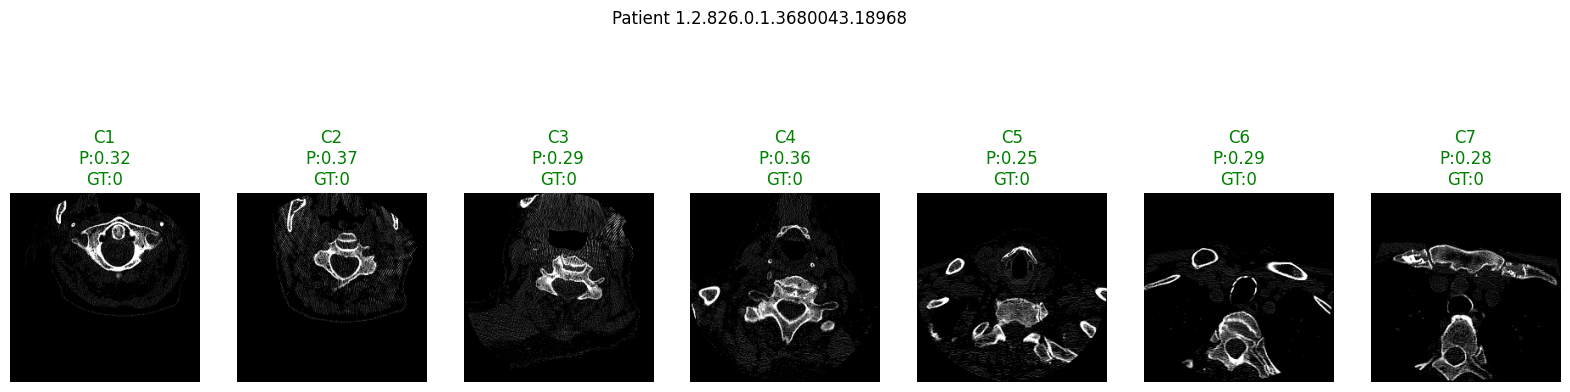

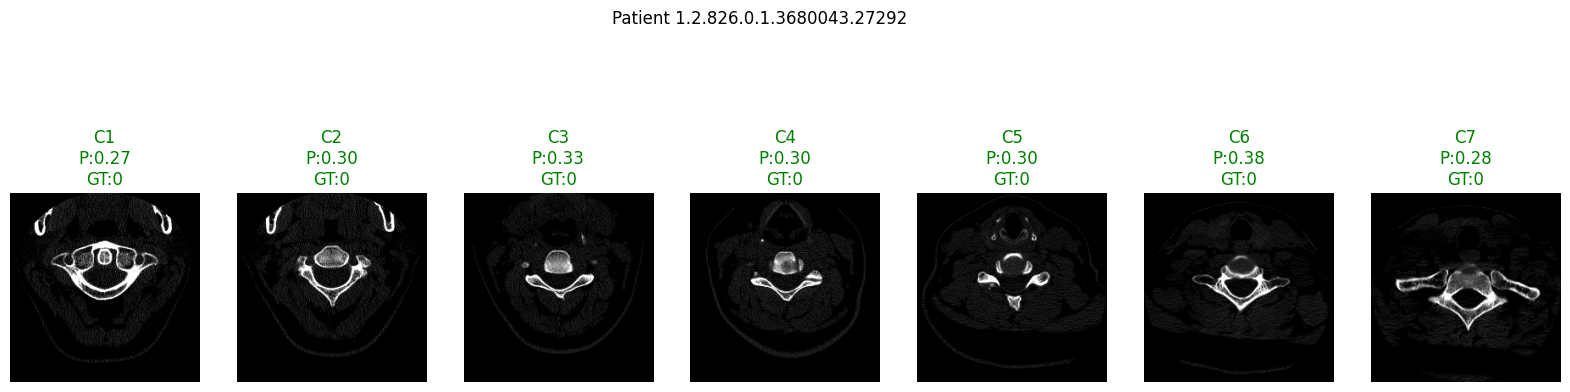

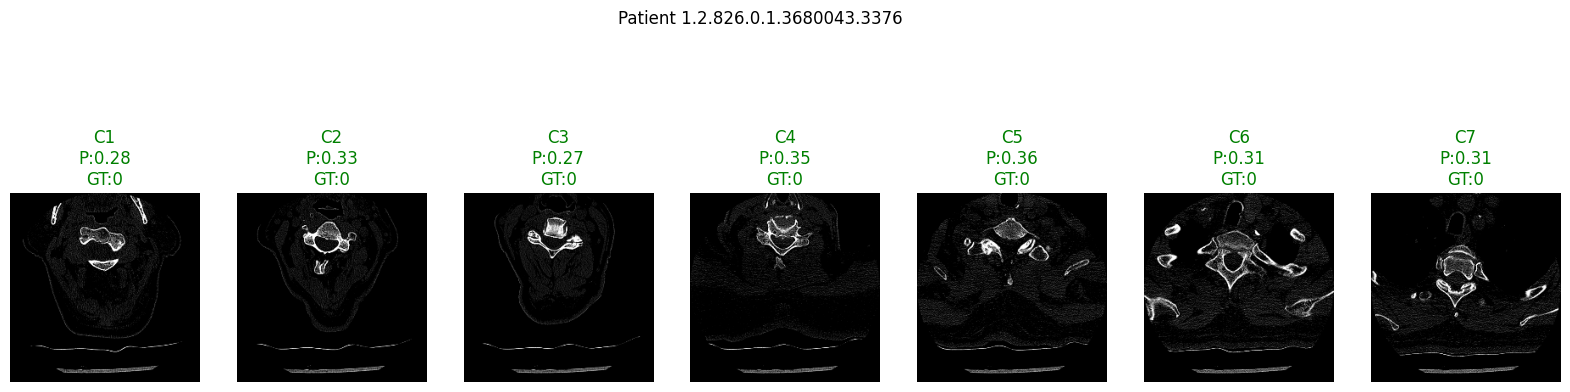

In [45]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, threshold=0.4, n=3):
    device = next(model.parameters()).device
    model.eval()

    idxs = np.random.choice(len(dataset), n, replace=False)

    for idx in idxs:
        x,y = dataset[idx]
        uid = dataset.df.iloc[idx]["StudyInstanceUID"]

        with torch.no_grad():
            p = torch.sigmoid(model(x.unsqueeze(0).to(device)))[0].cpu().numpy()

        fig, axs = plt.subplots(1,7, figsize=(20,5))
        fig.suptitle(f"Patient {uid}", y=1.05)

        for i in range(7):
            axs[i].imshow(x[i,3], cmap="gray")
            pred = p[i] > threshold
            color = "green" if pred == bool(y[i]) else "red"
            axs[i].set_title(f"C{i+1}\nP:{p[i]:.2f}\nGT:{int(y[i])}", color=color)
            axs[i].axis("off")

        plt.show()

val_viz = RSNADatasetAug(val_df, TRAIN_IMAGES_DIR, SEG_DIR, augment=False)
visualize_predictions(model, val_viz)

🔍 3 patients avec fractures trouvés dans le set de validation.


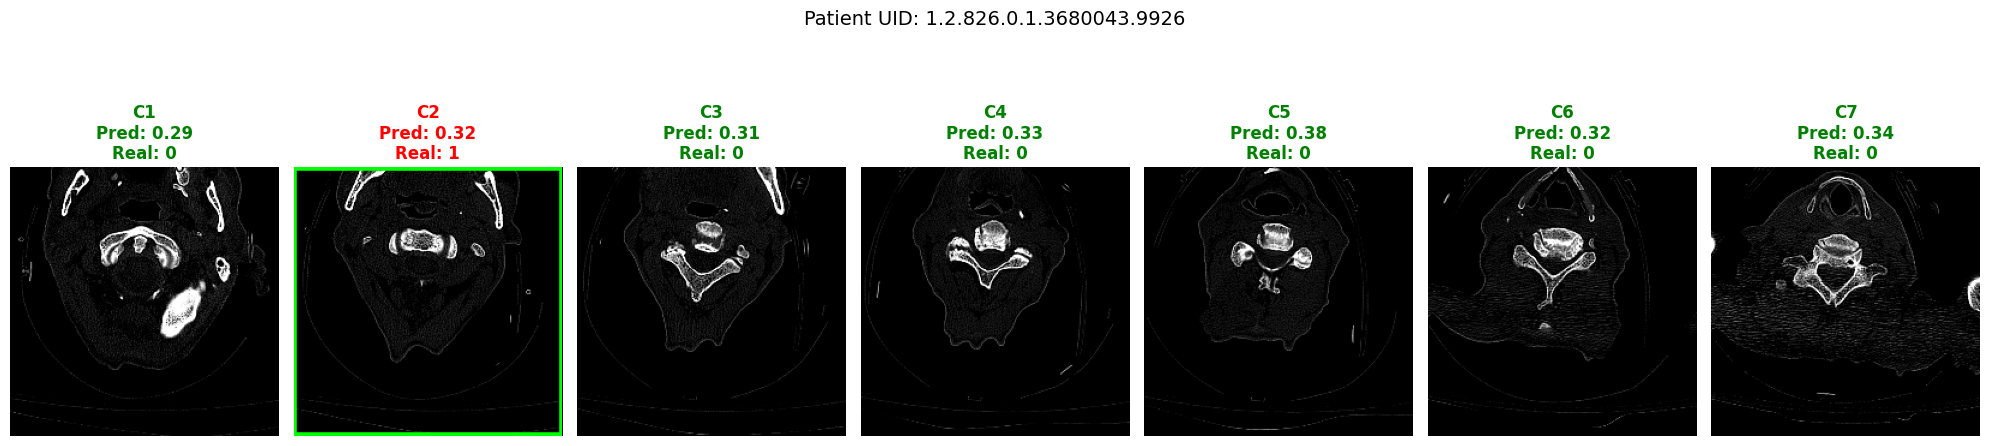

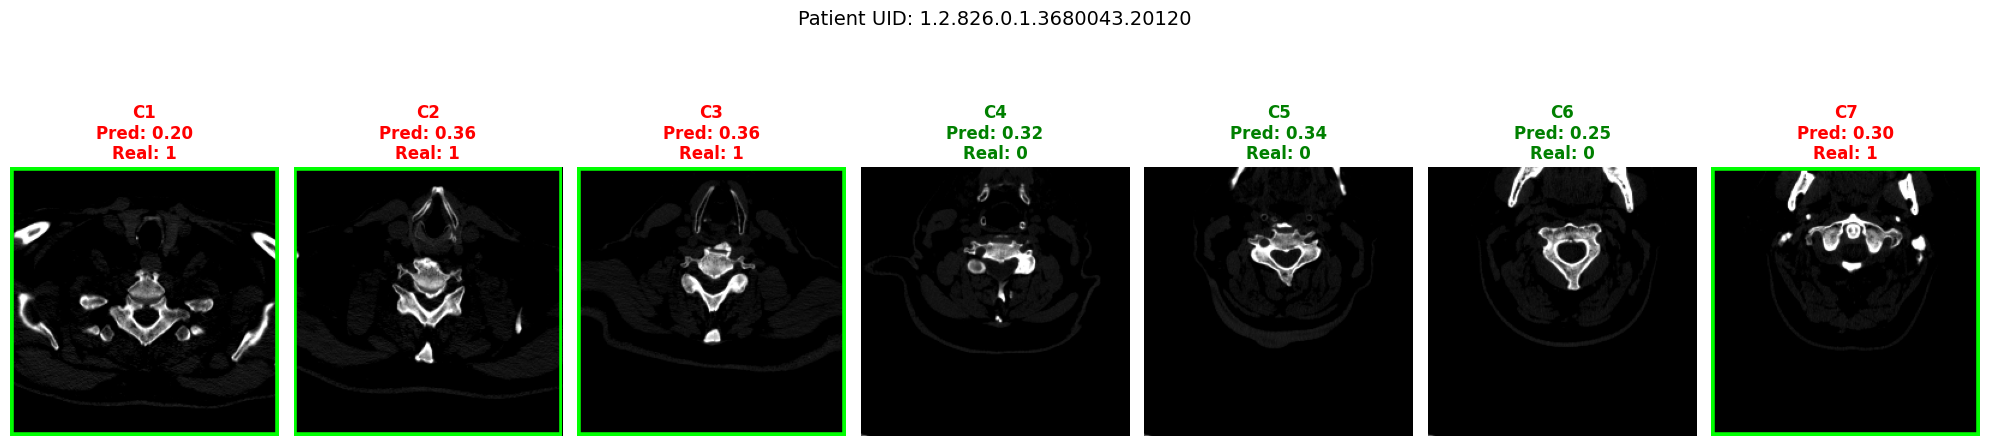

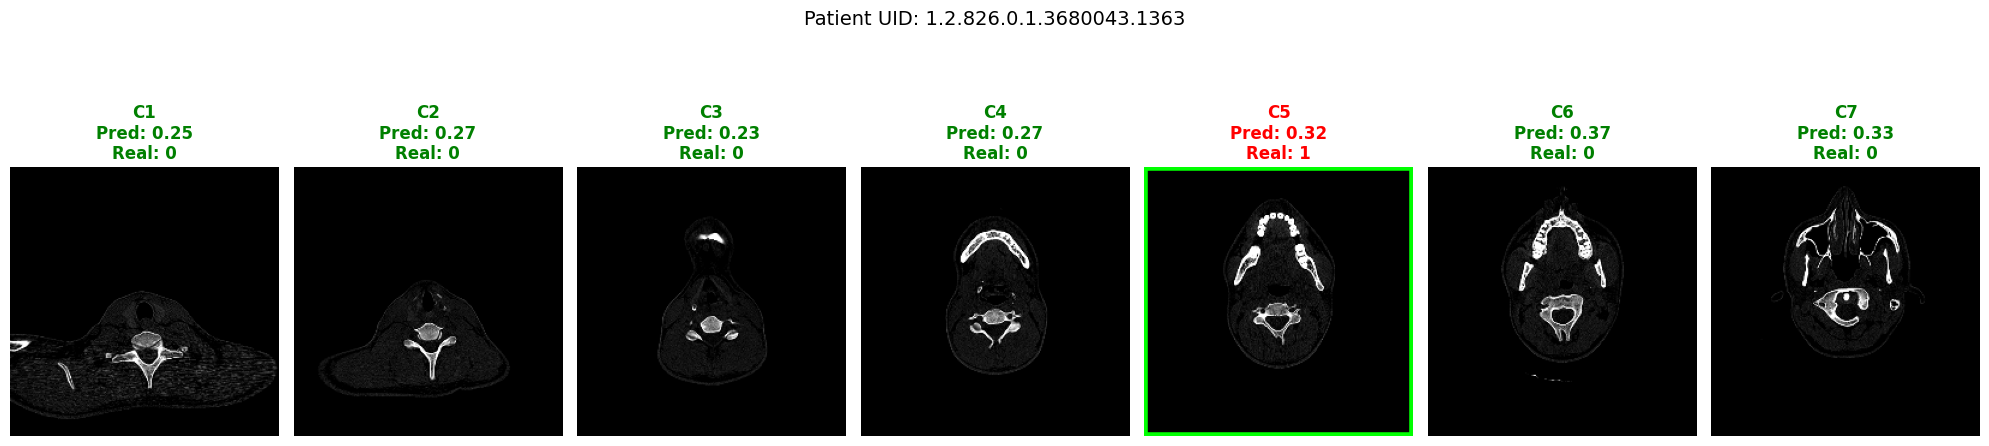

In [46]:
# --- CELLULE D'ANALYSE : FOCUS SUR LES FRACTURES RÉELLES ---

def inspecter_fractures_reelles(model, df_validation, image_dir, seg_dir, num_esempi=3):
    model.eval()
    # 1. On  ne garder que les patients ayant au moins une fracture
    df_fractures = df_validation[(df_validation[['C1','C2','C3','C4','C5','C6','C7']] == 1).any(axis=1)]
    
    if len(df_fractures) == 0:
        print(" Aucune fracture réelle n'a été trouvée dans le jeu de validation choisi.")
        return

    print(f"🔍 {len(df_fractures)} patients avec fractures trouvés dans le set de validation.")
    
    # 2. dataset temporaire avec ces patients
    dataset_fractures = RSNADatasetAug(df_fractures, image_dir, seg_dir, augment=False)
    
    # 3. fonction de visualisation sur ces cas précis
    
    n = min(num_esempi, len(df_fractures))
    visualizza_predizioni_correct(model, dataset_fractures, num_esempi=n)

# Lancement de l'inspection
inspecter_fractures_reelles(model, val_df, TRAIN_IMAGES_DIR, SEG_DIR, num_esempi=3)